# Patient Similarity Graph GAT — CVD Risk Prediction

Extends the ResNet18 CNN baseline (`china_fundus_cimt_pipeline.ipynb`) into a **patient similarity graph**
classified with a Graph Attention Network (GAT).

**Run the CNN baseline notebook first** — this notebook loads its saved model checkpoint (`best_model.pt`)
to extract image embeddings. Make sure `best_model.pt` and the patient ID split CSVs are in the same folder as this notebook.

## Pipeline
1. Load the trained ResNet18, extract its 512-dim penultimate-layer embedding for every image (both eyes)
2. Average left/right eye embeddings per patient -> one embedding vector per patient
3. Build a **patient similarity graph**: nodes = patients, node features = [image embedding + age_norm + gender],
   edges = k-nearest-neighbors by combined (embedding + age/gender) distance
4. Train a GAT for semi-supervised node classification (thickened vs normal)
5. Evaluate on the same test-set patients as the CNN baseline, for a fair comparison

**Novelty angle for the paper:** prior work (Reti-WHO transformer, IEEE CNN paper, Poplin et al.) treats each
fundus image independently. This models patients as a graph, letting a patient's prediction be informed by
clinically + visually similar patients via attention -- a fusion approach not present in the existing literature.


## 1. Setup

In [1]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from PIL import Image

from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report, roc_curve

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


/opt/anaconda3/envs/pbl_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


In [2]:
# Try importing torch_geometric; if missing, install it first.
try:
    import torch_geometric
    from torch_geometric.nn import GATConv
    from torch_geometric.data import Data
    print("torch_geometric already installed:", torch_geometric.__version__)
except ImportError:
    print("torch_geometric not found. Run this in a cell, then restart the kernel:")
    print()
    print("  import sys")
    print("  !{sys.executable} -m pip install torch_geometric")
    print()
    print("(No extra CUDA-specific wheels needed for CPU-only or MPS use -- the plain pip package works.)")


torch_geometric already installed: 2.8.0.post1


## 2. Paths (same as the CNN baseline notebook)

In [3]:
DATA_DIR  = "/Users/anushmita/Documents/Screenshots/pbl/retinal fundus dataset/Fundus_CIMT_2903 Dataset"
JSON_PATH = "/Users/anushmita/Documents/Screenshots/pbl/retinal fundus dataset/data_info.json"

CNN_CHECKPOINT = "best_model.pt"
TRAIN_IDS_CSV  = "train_patient_ids.csv"
VAL_IDS_CSV    = "val_patient_ids.csv"
TEST_IDS_CSV   = "test_patient_ids.csv"

IMG_SIZE = 224
K_NEIGHBORS = 15        # was 8 — mutual k-NN filtering already prunes aggressively, need more candidates
EMBED_WEIGHT = 0.6
GAT_HIDDEN = 128         # was 32 — restore capacity
GAT_HEADS = 8            # was 4
GAT_DROPOUT = 0.4        # was 0.5 — slightly less aggressive given restored capacity
GAT_EPOCHS = 300
GAT_LR = 1e-3
GAT_WEIGHT_DECAY = 1e-4  # was 5e-4


## 3. Load metadata (same schema as baseline: label, thickness, True_age, age, gender, left_eye, right_eye)

In [4]:
with open(JSON_PATH, "r") as f:
    meta = json.load(f)

rows = []
for patient_id, record in meta.items():
    label = record["label"]
    for side_key, side_name in [("left_eye", "L"), ("right_eye", "R")]:
        fname = record.get(side_key)
        if not fname:
            continue
        fpath = os.path.join(DATA_DIR, fname)
        if not os.path.exists(fpath):
            continue
        rows.append({
            "patient_id": patient_id,
            "filepath": fpath,
            "side": side_name,
            "true_age": record.get("True_age"),
            "age_norm": record.get("age"),
            "gender": record.get("gender"),
            "thickness": record.get("thickness"),
            "label": label
        })

df = pd.DataFrame(rows)
print(f"Total image rows: {len(df)}  |  Unique patients: {df.patient_id.nunique()}")


Total image rows: 5806  |  Unique patients: 2903


## 4. Reload the same train/val/test patient split used by the CNN baseline

In [5]:
train_ids = pd.read_csv(TRAIN_IDS_CSV, dtype=str)["patient_id"].str.strip().tolist()
val_ids   = pd.read_csv(VAL_IDS_CSV,   dtype=str)["patient_id"].str.strip().tolist()
test_ids  = pd.read_csv(TEST_IDS_CSV,  dtype=str)["patient_id"].str.strip().tolist()

df["patient_id"] = df["patient_id"].astype(str).str.strip()
print(f"Train: {len(train_ids)} | Val: {len(val_ids)} | Test: {len(test_ids)}")

overlap_test = set(test_ids) & set(df["patient_id"])
overlap_val  = set(val_ids)  & set(df["patient_id"])
print(f"Overlap -> val: {len(overlap_val)}, test: {len(overlap_test)}")
if len(overlap_test) == 0:
    print("Sample df ID:", df['patient_id'].unique()[:3].tolist())
    print("Sample test ID:", test_ids[:3])


Train: 2032 | Val: 435 | Test: 436
Overlap -> val: 435, test: 436


## 5. Load the trained CNN and extract per-image embeddings

Strips the final classification layer so the model outputs the 512-dim penultimate feature vector
instead of class logits.

In [6]:
resnet = models.resnet18(weights=None)
resnet.fc = nn.Linear(resnet.fc.in_features, 2)
resnet.load_state_dict(torch.load(CNN_CHECKPOINT, map_location=device))
resnet.fc = nn.Identity()   # strip classifier -> outputs 512-dim embedding
resnet = resnet.to(device)
resnet.eval()
print("Loaded CNN backbone for embedding extraction.")


Loaded CNN backbone for embedding extraction.


In [7]:
embed_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class ImageOnlyDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["filepath"]).convert("RGB")
        img = self.transform(img)
        return img, idx  # return row index so we can map embeddings back

embed_ds = ImageOnlyDataset(df, embed_transform)
embed_loader = DataLoader(embed_ds, batch_size=32, shuffle=False, num_workers=0)

all_embeddings = np.zeros((len(df), 512), dtype=np.float32)

with torch.no_grad():
    for imgs, idxs in embed_loader:
        imgs = imgs.to(device)
        feats = resnet(imgs).cpu().numpy()
        all_embeddings[idxs.numpy()] = feats

print("Extracted embeddings shape:", all_embeddings.shape)


Extracted embeddings shape: (5806, 512)


## 6. Aggregate to one embedding per patient (average left/right eye)

In [8]:
df["embed_idx"] = np.arange(len(df))

patient_records = []
for pid, group in df.groupby("patient_id"):
    idxs = group["embed_idx"].values
    avg_embedding = all_embeddings[idxs].mean(axis=0)
    patient_records.append({
        "patient_id": pid,
        "embedding": avg_embedding,
        "age_norm": group["age_norm"].iloc[0],
        "gender": group["gender"].iloc[0],
        "label": group["label"].iloc[0],
        "thickness": group["thickness"].iloc[0],
    })

patients_df = pd.DataFrame(patient_records)
print(f"Total patient nodes: {len(patients_df)}")
patients_df.head()


Total patient nodes: 2903


,patient_id,embedding,age_norm,gender,label,thickness
0,100464002,"[0.72087824, 0.8962835, 1.0450007, 1.2131737, ...",0.575342,1,1,1.1
1,100468003,"[1.7287598, 0.8851168, 1.3138181, 1.4830079, 0...",0.589041,0,1,1.0
2,10323005,"[0.8250252, 0.93311024, 0.6691812, 1.2770863, ...",0.534247,1,0,0.8
3,104191003,"[1.0329533, 0.93559855, 0.66128427, 1.3928497,...",0.452055,1,0,0.7
4,10510005,"[0.8583496, 1.2672498, 1.3110267, 1.3392332, 0...",0.671233,0,1,1.1


## 7. Build the patient similarity graph

Edges connect each patient to its k-nearest neighbors under a **combined distance**:
`EMBED_WEIGHT * (image embedding distance) + (1 - EMBED_WEIGHT) * (age/gender distance)`.

Both distance components are standardized first so neither dominates purely from having larger raw scale.

In [9]:
embed_matrix = np.stack(patients_df["embedding"].values)
embed_matrix_scaled = StandardScaler().fit_transform(embed_matrix)

clinical_matrix = patients_df[["age_norm", "gender"]].values.astype(np.float32)
clinical_matrix_scaled = StandardScaler().fit_transform(clinical_matrix)

combined_matrix = np.concatenate([
    np.sqrt(EMBED_WEIGHT) * embed_matrix_scaled,
    np.sqrt(1 - EMBED_WEIGHT) * clinical_matrix_scaled
], axis=1)

nbrs = NearestNeighbors(n_neighbors=K_NEIGHBORS + 1).fit(combined_matrix)
distances, indices = nbrs.kneighbors(combined_matrix)

neighbor_sets = [set(indices[i][1:]) for i in range(len(patients_df))]
edge_list, weight_list = [], []
for i in range(len(patients_df)):
    for pos, j in enumerate(indices[i][1:]):
        if i not in neighbor_sets[j]:   # mutual k-NN only
            continue
        d = distances[i][pos + 1]
        w = 1.0 / (1.0 + d)
        edge_list.append((i, j)); weight_list.append(w)
        edge_list.append((j, i)); weight_list.append(w)

edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
edge_attr = torch.tensor(weight_list, dtype=torch.float).unsqueeze(-1)
print(f"Graph: {len(patients_df)} nodes, {edge_index.shape[1]} edges (mutual k={K_NEIGHBORS})")

Graph: 2903 nodes, 32592 edges (mutual k=15)


## 8. Assemble node features, labels, and train/val/test masks

In [10]:
node_features = np.concatenate([embed_matrix, clinical_matrix], axis=1)
node_features = StandardScaler().fit_transform(node_features)

x = torch.tensor(node_features, dtype=torch.float)
y = torch.tensor(patients_df["label"].values, dtype=torch.long)

pid_to_idx = {pid: i for i, pid in enumerate(patients_df["patient_id"])}
train_mask = torch.zeros(len(patients_df), dtype=torch.bool)
val_mask   = torch.zeros(len(patients_df), dtype=torch.bool)
test_mask  = torch.zeros(len(patients_df), dtype=torch.bool)
for pid in train_ids:
    if pid in pid_to_idx: train_mask[pid_to_idx[pid]] = True
for pid in val_ids:
    if pid in pid_to_idx: val_mask[pid_to_idx[pid]] = True
for pid in test_ids:
    if pid in pid_to_idx: test_mask[pid_to_idx[pid]] = True

print(f"Train: {train_mask.sum().item()} | Val: {val_mask.sum().item()} | Test: {test_mask.sum().item()}")
assert test_mask.sum().item() > 0, "test_mask empty — fix cell 10's ID mismatch first."
assert val_mask.sum().item() > 0, "val_mask empty — fix cell 10's ID mismatch first."

graph_data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y,
                   train_mask=train_mask, val_mask=val_mask, test_mask=test_mask).to(device)


Train: 2032 | Val: 435 | Test: 436


## 9. GAT model

In [11]:
class PatientGAT(nn.Module):
    def __init__(self, in_dim, hidden_dim, heads, num_classes, dropout=0.5):
        super().__init__()
        self.dropout = dropout
        self.gat1 = GATConv(in_dim, hidden_dim, heads=heads, dropout=dropout, edge_dim=1)
        self.bn1 = nn.BatchNorm1d(hidden_dim * heads)
        self.gat2 = GATConv(hidden_dim * heads, num_classes, heads=1, concat=False, dropout=dropout, edge_dim=1)
        self.skip_proj = nn.Linear(in_dim, hidden_dim * heads)

    def forward(self, x, edge_index, edge_attr, return_attention=False):
        x_in = x
        x = F.dropout(x, p=self.dropout, training=self.training)
        h1, (edge_idx1, alpha1) = self.gat1(x, edge_index, edge_attr=edge_attr, return_attention_weights=True)
        h1 = self.bn1(h1); h1 = F.elu(h1)
        h1 = h1 + self.skip_proj(x_in)
        h1 = F.dropout(h1, p=self.dropout, training=self.training)
        out, (edge_idx2, alpha2) = self.gat2(h1, edge_index, edge_attr=edge_attr, return_attention_weights=True)
        if return_attention:
            return out, (edge_idx1, alpha1), (edge_idx2, alpha2)
        return out

model = PatientGAT(in_dim=x.shape[1], hidden_dim=GAT_HIDDEN, heads=GAT_HEADS,
                    num_classes=2, dropout=GAT_DROPOUT).to(device)
class_counts = torch.bincount(graph_data.y[graph_data.train_mask])
class_weights = 1.0 / torch.sqrt(class_counts.float())
class_weights = (class_weights / class_weights.sum() * 2).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.AdamW(model.parameters(), lr=GAT_LR, weight_decay=GAT_WEIGHT_DECAY)  # <-- ADD THIS LINE



## 10. Training loop

In [12]:
torch.manual_seed(SEED)
np.random.seed(SEED)

In [13]:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=GAT_EPOCHS)

def evaluate(mask):
    model.eval()
    with torch.no_grad():
        out = model(graph_data.x, graph_data.edge_index, graph_data.edge_attr)
        loss = criterion(out[mask], graph_data.y[mask]).item()
        preds = out[mask].argmax(dim=1)
        acc = (preds == graph_data.y[mask]).float().mean().item()
    return loss, acc

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_loss = float("inf")
patience, patience_counter = 30, 0

for epoch in range(GAT_EPOCHS):
    model.train()
    optimizer.zero_grad()
    out = model(graph_data.x, graph_data.edge_index, graph_data.edge_attr)
    loss = criterion(out[graph_data.train_mask], graph_data.y[graph_data.train_mask])
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step(); scheduler.step()

    train_loss, train_acc = evaluate(graph_data.train_mask)
    val_loss, val_acc = evaluate(graph_data.val_mask)
    history["train_loss"].append(train_loss); history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc); history["val_acc"].append(val_acc)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_gat_model.pt")
        patience_counter = 0
    else:
        patience_counter += 1

    if (epoch + 1) % 20 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{GAT_EPOCHS} | train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
              f"| val_loss={val_loss:.4f} val_acc={val_acc:.4f}")
    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break


Epoch 1/300 | train_loss=3.2847 train_acc=0.7372 | val_loss=3.9510 val_acc=0.6989
Epoch 20/300 | train_loss=0.6353 train_acc=0.7613 | val_loss=0.8834 val_acc=0.7333
Epoch 40/300 | train_loss=0.3199 train_acc=0.8617 | val_loss=0.6259 val_acc=0.7793
Epoch 60/300 | train_loss=0.2598 train_acc=0.8883 | val_loss=0.6114 val_acc=0.7839
Early stopping at epoch 72


## 11. Training curves

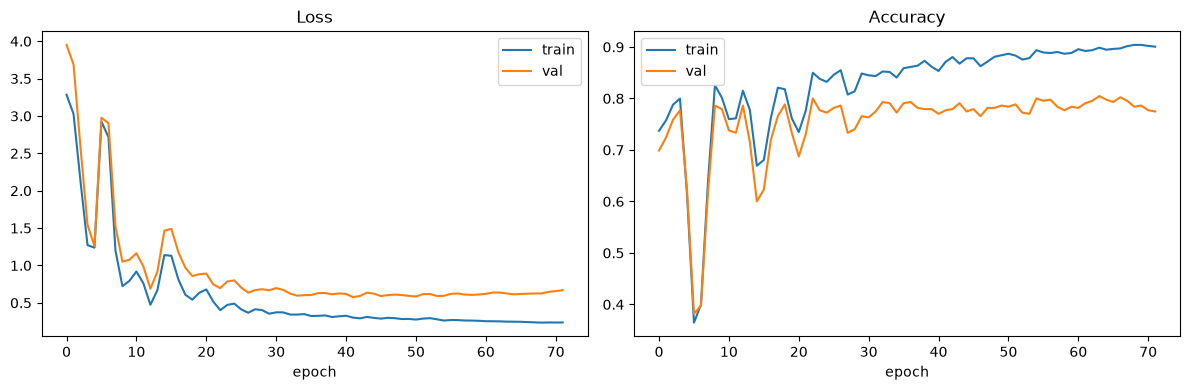

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss"); axes[0].set_xlabel("epoch"); axes[0].legend()

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="val")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("epoch"); axes[1].legend()
plt.tight_layout()
plt.show()


## 12. Test set evaluation (directly comparable to the CNN baseline's test metrics)

In [15]:
model.load_state_dict(torch.load("best_gat_model.pt"))
model.eval()
with torch.no_grad():
    out = model(graph_data.x, graph_data.edge_index, graph_data.edge_attr)
    all_probs = F.softmax(out, dim=1)[:, 1].cpu().numpy()

test_idx = graph_data.test_mask.cpu().numpy()
val_idx = graph_data.val_mask.cpu().numpy()
y_all = graph_data.y.cpu().numpy()

y_true_val, y_prob_val = y_all[val_idx], all_probs[val_idx]
y_true, y_prob = y_all[test_idx], all_probs[test_idx]

from sklearn.metrics import f1_score

best_thresh_f1, best_f1 = 0.5, -1
for t in np.arange(0.20, 0.81, 0.01):
    preds_t = (y_prob_val >= t).astype(int)
    f1_t = f1_score(y_true_val, preds_t)
    if f1_t > best_f1:
        best_f1, best_thresh_f1 = f1_t, t


print(f"F1-tuned threshold:   {best_thresh_f1:.2f} (val F1={best_f1:.4f})")
y_pred = (y_prob >= best_thresh_f1).astype(int)
acc = accuracy_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_prob)

print(f"Test Accuracy: {acc:.4f} | Test AUC-ROC: {auc:.4f}")

F1-tuned threshold:   0.30 (val F1=0.8648)
Test Accuracy: 0.7798 | Test AUC-ROC: 0.8195


In [16]:
model.load_state_dict(torch.load("best_gat_model.pt"))
model.eval()
with torch.no_grad():
    out = model(graph_data.x, graph_data.edge_index, graph_data.edge_attr)
    all_probs = F.softmax(out, dim=1)[:, 1].cpu().numpy()

test_idx = graph_data.test_mask.cpu().numpy()
val_idx = graph_data.val_mask.cpu().numpy()
y_all = graph_data.y.cpu().numpy()

y_true_val, y_prob_val = y_all[val_idx], all_probs[val_idx]
y_true, y_prob = y_all[test_idx], all_probs[test_idx]

# Threshold tuning with a sensitivity floor
MIN_SENSITIVITY = 0.85
best_thresh, best_acc = 0.5, 0
for t in np.arange(0.20, 0.81, 0.01):
    preds_t = (y_prob_val >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true_val, preds_t).ravel()
    sens = tp / (tp + fn) if (tp + fn) else 0
    if sens < MIN_SENSITIVITY:
        continue
    a = accuracy_score(y_true_val, preds_t)
    if a > best_acc:
        best_acc, best_thresh = a, t

print(f"Threshold with sensitivity >= {MIN_SENSITIVITY}: {best_thresh:.2f} (val acc: {best_acc:.4f})")

y_pred = (y_prob >= best_thresh).astype(int)
acc = accuracy_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_prob)

tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
ppv = tp / (tp + fp)
npv = tn / (tn + fn)
f1 = 2 * (ppv * sensitivity) / (ppv + sensitivity)
youden_j = sensitivity + specificity - 1
balanced_acc = (sensitivity + specificity) / 2

print(f"\nGAT Test Accuracy: {acc:.4f}")
print(f"GAT Test AUC-ROC:  {auc:.4f}")
print(f"Sensitivity:       {sensitivity:.4f}")

Threshold with sensitivity >= 0.85: 0.30 (val acc: 0.8023)

GAT Test Accuracy: 0.7798
GAT Test AUC-ROC:  0.8195
Sensitivity:       0.8864


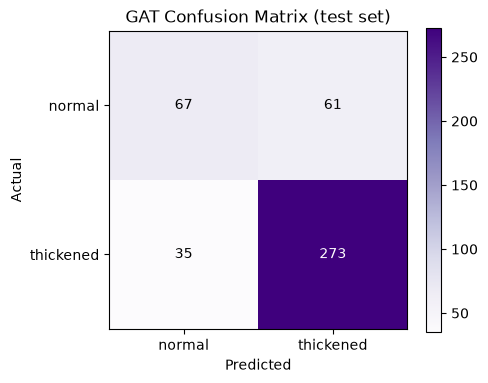

In [19]:
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Purples")
ax.set_xticks([0, 1]); ax.set_xticklabels(["normal", "thickened"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["normal", "thickened"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black")
plt.title("GAT Confusion Matrix (test set)")
plt.colorbar(im)
plt.tight_layout()
plt.show()


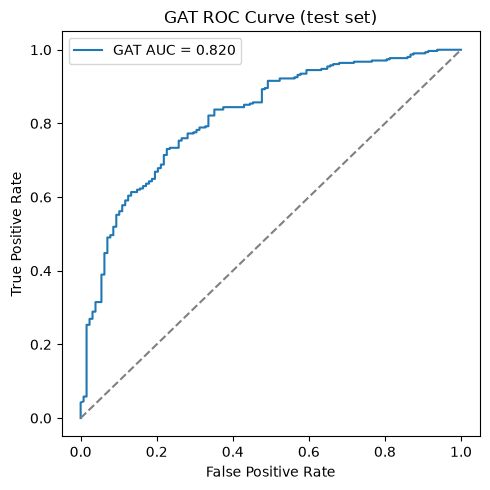

In [20]:
fpr, tpr, _ = roc_curve(y_true, y_prob)
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"GAT AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("GAT ROC Curve (test set)")
plt.legend()
plt.tight_layout()
plt.show()


## 13. Attention weight inspection (interpretability angle for the paper)

Extracts which neighbor edges the model attended to most strongly for a handful of test patients —
this is your interpretability story: "the model's prediction for patient X was most influenced by
patients A, B, C, who are clinically/visually similar."

In [21]:
model.eval()
with torch.no_grad():
    _, (edge_idx1, alpha1), _ = model(graph_data.x, graph_data.edge_index, graph_data.edge_attr, return_attention=True)

# alpha1 shape: [num_edges, num_heads] -- average across heads for a single importance score per edge
edge_importance = alpha1.mean(dim=1).cpu().numpy()
edge_src = edge_idx1[0].cpu().numpy()
edge_dst = edge_idx1[1].cpu().numpy()

# Look at one example test patient
example_test_idx = np.where(test_idx)[0][0]
example_pid = patients_df.iloc[example_test_idx]["patient_id"]

mask = edge_dst == example_test_idx
neighbor_srcs = edge_src[mask]
neighbor_importance = edge_importance[mask]

top_order = np.argsort(-neighbor_importance)[:5]
print(f"Patient {example_pid} (test set) -- top attended neighbors:")
for rank, i in enumerate(top_order):
    neighbor_pid = patients_df.iloc[neighbor_srcs[i]]["patient_id"]
    neighbor_label = patients_df.iloc[neighbor_srcs[i]]["label"]
    print(f"  {rank+1}. Patient {neighbor_pid} (label={neighbor_label}), attention weight={neighbor_importance[i]:.4f}")


Patient 100464002 (test set) -- top attended neighbors:
  1. Patient 100464002 (label=1), attention weight=0.3693
  2. Patient 135301003 (label=1), attention weight=0.1830
  3. Patient 135301003 (label=1), attention weight=0.1830
  4. Patient 469984004 (label=1), attention weight=0.1323
  5. Patient 469984004 (label=1), attention weight=0.1323


In [22]:
# Bootstrap 95% CI for AUC-ROC
n_bootstraps = 1000
rng = np.random.RandomState(SEED)
bootstrapped_aucs_gat = []

for i in range(n_bootstraps):
    indices = rng.randint(0, len(y_prob), len(y_prob))
    if len(np.unique(y_true[indices])) < 2:
        continue
    score = roc_auc_score(y_true[indices], y_prob[indices])
    bootstrapped_aucs_gat.append(score)

ci_lower = np.percentile(bootstrapped_aucs_gat, 2.5)
ci_upper = np.percentile(bootstrapped_aucs_gat, 97.5)
print(f"GAT AUC-ROC: {auc:.4f}  (95% CI: {ci_lower:.4f} - {ci_upper:.4f}, n_bootstrap={len(bootstrapped_aucs_gat)})")

np.save("gat_bootstrap_aucs.npy", np.array(bootstrapped_aucs_gat))

GAT AUC-ROC: 0.8195  (95% CI: 0.7789 - 0.8579, n_bootstrap=1000)


In [23]:
# Load CNN's per-image test probabilities + patient IDs
cnn_probs_img = np.load("cnn_test_probs.npy")
cnn_pids_img = pd.read_csv("cnn_test_probs_pids.csv")["patient_id"].astype(str).values

cnn_df = pd.DataFrame({"patient_id": cnn_pids_img, "cnn_prob": cnn_probs_img})
cnn_patient_probs = cnn_df.groupby("patient_id")["cnn_prob"].mean()  # average L/R eye

# Align to GAT's test patient order
test_pids_ordered = patients_df.iloc[np.where(test_idx)[0]]["patient_id"].values
cnn_aligned = cnn_patient_probs.loc[test_pids_ordered].values

# Try a few ensemble weightings
for w_gat in [0.3, 0.4, 0.5, 0.6, 0.7]:
    ens_probs = (1 - w_gat) * cnn_aligned + w_gat * y_prob
    ens_preds = (ens_probs >= 0.5).astype(int)
    ens_acc = accuracy_score(y_true, ens_preds)
    ens_auc = roc_auc_score(y_true, ens_probs)
    print(f"GAT weight={w_gat}: Accuracy={ens_acc:.4f}  AUC={ens_auc:.4f}")

GAT weight=0.3: Accuracy=0.7913  AUC=0.8465
GAT weight=0.4: Accuracy=0.7844  AUC=0.8448
GAT weight=0.5: Accuracy=0.7867  AUC=0.8412
GAT weight=0.6: Accuracy=0.7798  AUC=0.8377
GAT weight=0.7: Accuracy=0.7683  AUC=0.8341


In [25]:
BEST_W_GAT = 0.3  # update based on your latest ensemble weight results

ens_probs_test = (1 - BEST_W_GAT) * cnn_aligned + BEST_W_GAT * y_prob

cnn_val_probs = np.load("cnn_val_probs.npy")
cnn_val_pids = pd.read_csv("cnn_val_probs_pids.csv")["patient_id"].astype(str).values

cnn_val_df = pd.DataFrame({"patient_id": cnn_val_pids, "cnn_prob": cnn_val_probs})
cnn_val_patient_probs = cnn_val_df.groupby("patient_id")["cnn_prob"].mean()

val_pids_ordered = patients_df.iloc[np.where(val_idx)[0]]["patient_id"].values
cnn_val_aligned = cnn_val_patient_probs.loc[val_pids_ordered].values

model.eval()
with torch.no_grad():
    out = model(graph_data.x, graph_data.edge_index, graph_data.edge_attr)
    gat_val_probs = F.softmax(out, dim=1)[:, 1].cpu().numpy()[graph_data.val_mask.cpu().numpy()]
    gat_val_labels = graph_data.y.cpu().numpy()[graph_data.val_mask.cpu().numpy()]

n = min(len(cnn_val_aligned), len(gat_val_probs))
ens_val_probs = (1 - BEST_W_GAT) * cnn_val_aligned[:n] + BEST_W_GAT * gat_val_probs[:n]
ens_val_labels = gat_val_labels[:n]

# --- Now the threshold tuning ---
MIN_SENSITIVITY = 0.85

best_thresh, best_acc = 0.5, 0
for t in np.arange(0.20, 0.81, 0.01):
    preds_t = (ens_val_probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(ens_val_labels, preds_t).ravel()
    sens = tp / (tp + fn) if (tp + fn) else 0
    if sens < MIN_SENSITIVITY:
        continue
    a = accuracy_score(ens_val_labels, preds_t)
    if a > best_acc:
        best_acc, best_thresh = a, t

print(f"Ensemble threshold with sensitivity >= {MIN_SENSITIVITY}: {best_thresh:.2f} (val acc: {best_acc:.4f})")

ens_preds_tuned = (ens_probs_test >= best_thresh).astype(int)
final_acc = accuracy_score(y_true, ens_preds_tuned)
final_auc = roc_auc_score(y_true, ens_probs_test)

tn, fp, fn, tp = confusion_matrix(y_true, ens_preds_tuned).ravel()
sensitivity, specificity = tp/(tp+fn), tn/(tn+fp)
ppv, npv = tp/(tp+fp), tn/(tn+fn)
f1 = 2*(ppv*sensitivity)/(ppv+sensitivity)
youden_j = sensitivity + specificity - 1
balanced_acc = (sensitivity + specificity) / 2

print(f"\n--- Final Ensemble (w_gat={BEST_W_GAT}, threshold={best_thresh:.2f}) ---")
print(f"Accuracy:      {final_acc:.4f}")
print(f"AUC-ROC:       {final_auc:.4f}")
print(f"Sensitivity:   {sensitivity:.4f}")
print(f"Specificity:   {specificity:.4f}")
print(f"PPV:           {ppv:.4f}")
print(f"NPV:           {npv:.4f}")
print(f"F1-score:      {f1:.4f}")
print(f"Youden's J:    {youden_j:.4f}")
print(f"Balanced Acc:  {balanced_acc:.4f}")

Ensemble threshold with sensitivity >= 0.85: 0.38 (val acc: 0.8092)

--- Final Ensemble (w_gat=0.3, threshold=0.38) ---
Accuracy:      0.8096
AUC-ROC:       0.8465
Sensitivity:   0.9351
Specificity:   0.5078
PPV:           0.8205
NPV:           0.7647
F1-score:      0.8741
Youden's J:    0.4429
Balanced Acc:  0.7214


In [26]:
MIN_SENSITIVITY = 0.85
results = []

for w_gat in np.arange(0.15, 0.46, 0.05):  # finer sweep around your best region (0.3 was best)
    ens_probs_test_w = (1 - w_gat) * cnn_aligned + w_gat * y_prob
    ens_val_probs_w = (1 - w_gat) * cnn_val_aligned[:n] + w_gat * gat_val_probs[:n]

    best_t, best_a = 0.5, 0
    for t in np.arange(0.20, 0.81, 0.01):
        preds_t = (ens_val_probs_w >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(ens_val_labels, preds_t).ravel()
        sens = tp / (tp + fn) if (tp + fn) else 0
        if sens < MIN_SENSITIVITY:
            continue
        a = accuracy_score(ens_val_labels, preds_t)
        if a > best_a:
            best_a, best_t = a, t

    final_preds = (ens_probs_test_w >= best_t).astype(int)
    final_acc = accuracy_score(y_true, final_preds)
    final_auc = roc_auc_score(y_true, ens_probs_test_w)
    results.append((w_gat, best_t, final_acc, final_auc))
    print(f"w_gat={w_gat:.2f}  thresh={best_t:.2f}  test_acc={final_acc:.4f}  test_auc={final_auc:.4f}")

best_result = max(results, key=lambda r: r[2])
print(f"\nBest: w_gat={best_result[0]:.2f}  threshold={best_result[1]:.2f}  accuracy={best_result[2]:.4f}")

w_gat=0.15  thresh=0.57  test_acc=0.7798  test_auc=0.8488
w_gat=0.20  thresh=0.40  test_acc=0.8096  test_auc=0.8486
w_gat=0.25  thresh=0.40  test_acc=0.8096  test_auc=0.8477
w_gat=0.30  thresh=0.38  test_acc=0.8096  test_auc=0.8465
w_gat=0.35  thresh=0.48  test_acc=0.7913  test_auc=0.8457
w_gat=0.40  thresh=0.48  test_acc=0.7890  test_auc=0.8448
w_gat=0.45  thresh=0.38  test_acc=0.8119  test_auc=0.8430

Best: w_gat=0.45  threshold=0.38  accuracy=0.8119


In [27]:
w_gat = 0.45
thresh = 0.38

ens_probs_test_final = (1 - w_gat) * cnn_aligned + w_gat * y_prob
final_preds = (ens_probs_test_final >= thresh).astype(int)

final_acc = accuracy_score(y_true, final_preds)
final_auc = roc_auc_score(y_true, ens_probs_test_final)

tn, fp, fn, tp = confusion_matrix(y_true, final_preds).ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
ppv = tp / (tp + fp)
npv = tn / (tn + fn)
f1 = 2 * (ppv * sensitivity) / (ppv + sensitivity)
youden_j = sensitivity + specificity - 1
balanced_acc = (sensitivity + specificity) / 2

print(f"--- Final Ensemble (w_gat={w_gat}, threshold={thresh}) ---")
print(f"Accuracy:      {final_acc:.4f}")
print(f"AUC-ROC:       {final_auc:.4f}")
print(f"Sensitivity:   {sensitivity:.4f}")
print(f"Specificity:   {specificity:.4f}")
print(f"PPV:           {ppv:.4f}")
print(f"NPV:           {npv:.4f}")
print(f"F1-score:      {f1:.4f}")
print(f"Youden's J:    {youden_j:.4f}")
print(f"Balanced Acc:  {balanced_acc:.4f}")

--- Final Ensemble (w_gat=0.45, threshold=0.38) ---
Accuracy:      0.8119
AUC-ROC:       0.8430
Sensitivity:   0.9253
Specificity:   0.5391
PPV:           0.8285
NPV:           0.7500
F1-score:      0.8742
Youden's J:    0.4644
Balanced Acc:  0.7322
